In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from pycontrails import Fleet

In [2]:
# EGWP 100
dff_egwp100 = pd.read_parquet("../data/filed/filed_trajectories_EAGWP100.parquet")
fleetf_egwp100 = Fleet(data=dff_egwp100)

dfo_egwp100 = pd.read_parquet("../data/optimised/optimised_trajectories_EAGWP100.parquet")
fleeto_egwp100 = Fleet(data=dfo_egwp100)

In [3]:
# EGWP 20
dff_egwp20 = pd.read_parquet("../data/filed/filed_trajectories_EAGWP20.parquet")
fleetf_egwp20 = Fleet(data=dff_egwp20)

dfo_egwp20 = pd.read_parquet("../data/optimised/optimised_trajectories_EAGWP20.parquet")
fleeto_egwp20 = Fleet(data=dfo_egwp20)

In [4]:
# ATR 100
dff_atr100 = pd.read_parquet("../data/filed/filed_trajectories_ATR100.parquet")
fleetf_atr100 = Fleet(data=dff_atr100)

dfo_atr100 = pd.read_parquet("../data/optimised/optimised_trajectories_ATR100.parquet")
fleeto_atr100 = Fleet(data=dfo_atr100)

In [5]:
from cane.utils import mask_by_marker
from cane.utils import mask_by_validity_range

fleets = {
    'egwp100': (fleetf_egwp100, fleeto_egwp100),
    'egwp20': (fleetf_egwp20, fleeto_egwp20),
    'atr100': (fleetf_atr100, fleeto_atr100),
}

markers = ["NOx", "O3", "CH4", "H2O"]
bounds = [150, 350]

for key, (fleetf, fleeto) in fleets.items():

    mask_by_marker(fleetf, markers)
    mask_by_marker(fleeto, markers)
    
    mask_by_validity_range(fleetf, markers, bounds)
    mask_by_validity_range(fleeto, markers, bounds)
    
    dff = fleetf.dataframe
    dfo = fleeto.dataframe

    dff["Total"] = dff["CO2"] + dff["CoCiP"] + dff["NOx"] + dff["H2O"]
    dfo["Total"] = dfo["CO2"] + dfo["CoCiP"] + dfo["NOx"] + dfo["H2O"]

    globals()[f'dff_{key}'] = dff
    globals()[f'dfo_{key}'] = dfo

Marked rows filtered out for NOx
Marked rows filtered out for O3
Marked rows filtered out for CH4
Marked rows filtered out for H2O
Marked rows filtered out for NOx
Marked rows filtered out for O3
Marked rows filtered out for CH4
Marked rows filtered out for H2O
Bounds of [150, 350] in place for NOx
Bounds of [150, 350] in place for O3
Bounds of [150, 350] in place for CH4
Bounds of [150, 350] in place for H2O
Bounds of [150, 350] in place for NOx
Bounds of [150, 350] in place for O3
Bounds of [150, 350] in place for CH4
Bounds of [150, 350] in place for H2O
Marked rows filtered out for NOx
Marked rows filtered out for O3
Marked rows filtered out for CH4
Marked rows filtered out for H2O
Marked rows filtered out for NOx
Marked rows filtered out for O3
Marked rows filtered out for CH4
Marked rows filtered out for H2O
Bounds of [150, 350] in place for NOx
Bounds of [150, 350] in place for O3
Bounds of [150, 350] in place for CH4
Bounds of [150, 350] in place for H2O
Bounds of [150, 350] in

In [6]:
from cane.utils import df_diff

cols_to_sum = ["flight_id", "fuel_burn", "nox", "co2", "CO2", "NOx", "CoCiP", "H2O", "Total"]

for key in fleets.keys():
    
    dff = globals()[f'dff_{key}']
    dfo = globals()[f'dfo_{key}']

    # create aggregates (total)
    org_sum = (
        dff[cols_to_sum].groupby(["flight_id"]).sum().reset_index()
    )
    opt_sum = (
        dfo[cols_to_sum].groupby(["flight_id"]).sum().reset_index()
    )
    my_diff = df_diff(org_sum, opt_sum, on=["flight_id"], keep_originals=True)
    my_diff = pd.merge(
        my_diff,
        dff.groupby("flight_id").day.first(),
        on="flight_id",
    )
    
    globals()[f'my_diff_{key}'] = my_diff.copy()


In [7]:
from cane.labels import friendly_days, friendly_days_in_2_rows
n_flights = [my_diff.query("day == @day").shape[0] for day in range(1, 9)]
day_labels = [
    f"{a}\n{b} flights"
    for a, b in zip(friendly_days, n_flights)
]

In [8]:
cols_for_plot = ["CO2_diff", "NOx_diff", "H2O_diff", "CoCiP_diff", "Total_diff"]

dfs = [my_diff_egwp100, my_diff_atr100, my_diff_egwp20]
dfs = [
    df.groupby("day")[cols_for_plot].sum().sort_values(by="day") for df in dfs
]
dfs[0] = dfs[0] / 1e3  # tons
dfs[1] = dfs[1] / 1e3  # tons
dfs[2] = dfs[2] / 1e3  # tons

In [9]:
sns.color_palette("Oranges")

[(0.9955709342560554, 0.8907958477508651, 0.7855132641291811),
 (0.9921568627450981, 0.7769934640522875, 0.5727028066128412),
 (0.9921568627450981, 0.6280507497116494, 0.34226835832372166),
 (0.9648442906574395, 0.47100346020761247, 0.14197616301422528),
 (0.8782929642445213, 0.31990772779700116, 0.024405997693194924),
 (0.6768627450980392, 0.22089965397923875, 0.010749711649365626)]

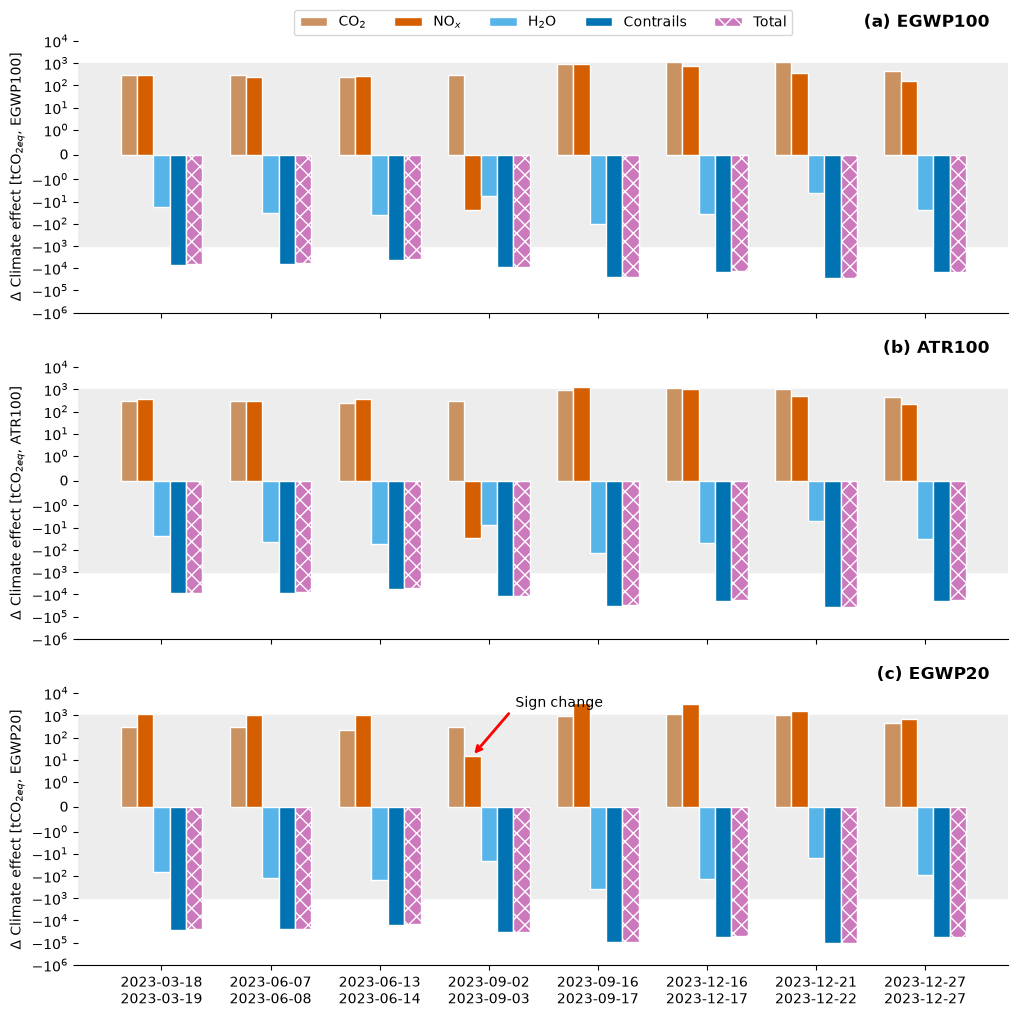

In [10]:
from cane.colors import colors, sns_idx

colors = [
    colors[sns_idx["brown"]], colors[sns_idx["red"]],
    colors[sns_idx["lightblue"]], colors[sns_idx["darkblue"]], colors[sns_idx["violet"]]
]
friendly_labels = [
    "CO$_2$", "NO$_x$", "H$_2$O", "Contrails", "Total"
]

fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharey=False, sharex=True)

for ax, df in zip(axes, dfs):
    n_groups = df.shape[0]  # 8
    n_bars = df.shape[1]  # 5
    x = np.arange(n_groups)
    bar_width = 0.15

    # Plot each column as a separate bar
    for i, col in enumerate(df.columns):
        ax.bar(
            x + i * bar_width,
            df[col],
            width=bar_width,
            color=colors[i],
            label=friendly_labels[i],
            hatch="xx" if i == n_bars - 1 else "",
            edgecolor="white",
            zorder=3
        )

    # Formatting
    ax.set_xticks(x + bar_width * (n_bars - 1) / 2)
    ax.set_xticklabels(friendly_days_in_2_rows)  #, rotation=45, ha="right")
    ax.set_yscale('symlog', linthresh=1)
    ax.set_ylim([-1e6, 1e4])
    # ax.grid(axis='y', linestyle='--', color='gray', alpha=0.7, zorder=0)
    # ax.axhline(0, linestyle='--', color='gray', alpha=0.7, zorder=10)
    ax.axhspan(-1e3, 1e3, color=sns.color_palette("Greys")[0])
    # ax.axhspan(-1e3, 0, color=sns.color_palette("Blues")[1])
    # ax.axhspan(0, 1e3, color=sns.color_palette("Reds")[1])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(True)

axes[0].set_ylabel("$\Delta$ Climate effect [tCO$_{2eq}$, EGWP100]")
axes[1].set_ylabel("$\Delta$ Climate effect [tCO$_{2eq}$, ATR100]")
axes[2].set_ylabel("$\Delta$ Climate effect [tCO$_{2eq}$, EGWP20]")

axes[0].legend(loc="upper center", ncol=5, bbox_to_anchor=(0.5, 1.14))  #, fontsize=12)

axes[0].text(
    0.98, 1.1, "(a) EGWP100", zorder=100,
    transform=axes[0].transAxes,
    fontsize=12, fontweight="bold",
    va="top", ha="right"
)

axes[1].text(
    0.98, 1.1, "(b) ATR100", zorder=100,
    transform=axes[1].transAxes,
    fontsize=12, fontweight="bold",
    va="top", ha="right"
)

axes[2].text(
    0.98, 1.1, "(c) EGWP20", zorder=100,
    transform=axes[2].transAxes,
    fontsize=12, fontweight="bold",
    va="top", ha="right"
)

axes[2].annotate(
    '',  # no text
    xy=(3.15, 15),  # arrow tip
    xytext=(3.5, 1500),  # arrow tail
    arrowprops=dict(facecolor='red', edgecolor='red', arrowstyle='->', lw=2),
    zorder=5
)
axes[2].text(
    0.47, 0.99, "Sign change", zorder=100,
    transform=axes[2].transAxes,
    fontsize=10,
    va="top", ha="left"
)

plt.savefig("../figures/fig11.png", dpi=300, bbox_inches="tight")